In [4]:
from dynamicTasteDistortion.ioUtils import read_experiment
from dynamicTasteDistortion.simulationConstants import (
    input_size_to_file_name,
    RESULTS_PATH,
)
import pandas as pd

# Click position analysis


In this notebook I'll look at the average click position for each algorithm and the average number of interaction per round

In [5]:
bpr_debiased = "experiments/bpr_unbiased_uncalibrated.yaml"
bpr_biased = "experiments/bpr_classic_uncalibrated.yaml"
random_rec = "experiments/random_rec_uncalibrated.yaml"
most_popular = "experiments/most_popular_uncalibrated.yaml"

# Calibrated ones
bpr_biased_calibrated_constant = "experiments/bpr_classic_calibrated_constant.yaml"
bpr_biased_calibrated_time = "experiments/bpr_classic_calibrated_time_based.yaml"

bpr_debiased_calibrated_constant = "experiments/bpr_unbiased_calibrated_constant.yaml"
bpr_debiased_calibrated_time = "experiments/bpr_unbiased_calibrated_time_based.yaml"


In [6]:
bpr_debiased_exp = read_experiment(bpr_debiased)

In [7]:
bpr_debiased_exp

{'size': 's',
 'data': 'ml',
 'rounds': 500,
 'num_rounds_per_eval': 5,
 'num_users': 1000,
 'model': 'bpr',
 'preference_update_rate': 0.1,
 'exp_name': 'bpr_unbiased_uncalibrated'}

In [8]:
from pathlib import Path


def get_experiment_artifact_path(cfg):
    rounds = int(cfg["rounds"])
    num_rounds_per_eval = int(cfg["num_rounds_per_eval"])
    num_users = int(cfg["num_users"])

    data_type = cfg["data"]
    size = cfg["size"]
    file_size = input_size_to_file_name[size]
    exp_name = cfg.get("exp_name", "default_experiment")

    base_artifacts_path = (
        Path(RESULTS_PATH)
        / f"{data_type}_{file_size}"
        / "simulated"
        / f"exp={exp_name}"
        / f"rounds={rounds}"
        / f"users={num_users}"
        / f"eval_every={num_rounds_per_eval}"
    )

    return str(base_artifacts_path)

In [9]:
path = get_experiment_artifact_path(bpr_debiased_exp)

In [10]:
simulation_df = pd.read_pickle(f"{path}/simulated_interactions.pkl")

In [11]:
simulation_df

,user,item,relevant,clicked_at,timestamp,rating,constant,genres,linear_time,round
0,0,997,1.0,0,0.006199,4.177124,1.0,NaN,NaN,1.0
1,0,1022,1.0,1,0.056479,4.171705,1.0,NaN,NaN,1.0
2,0,764,1.0,2,0.133365,4.135020,1.0,NaN,NaN,1.0
3,0,632,1.0,3,0.141593,4.121809,1.0,NaN,NaN,1.0
4,0,818,1.0,4,0.133878,4.120290,1.0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...
26650,926,1017,1.0,0,108.053520,5.199515,1.0,NaN,NaN,500.0
26651,927,2955,1.0,3,98.901392,5.195721,1.0,NaN,NaN,500.0
26652,962,1039,1.0,4,109.874321,3.401626,1.0,NaN,NaN,500.0
26653,974,2813,1.0,2,130.648249,4.186590,1.0,NaN,NaN,500.0


In [12]:
i = 1
round_i = simulation_df[simulation_df["round"] == i]

mrr_df = round_i.groupby("user").agg({"clicked_at": lambda group: sorted(list(group))[0]}).reset_index()

In [13]:
def calculate_mrr(round_df):
    mrr_df = (
        round_df.groupby("user")
        .agg({"clicked_at": min})
        .reset_index()
    )
    mrr_df["reciprocal_rank"] = 1/(mrr_df["clicked_at"] + 1)
    mrr = mrr_df["reciprocal_rank"].mean()
    return mrr

In [14]:
mrr_df["reciprocal_rank"] = 1/(mrr_df["clicked_at"] + 1)

In [15]:
mrr = mrr_df["reciprocal_rank"].mean()

In [16]:
mrr

0.5800042947894954

In [17]:
mrr_df

,user,clicked_at,reciprocal_rank
0,0,0,1.00
1,2,0,1.00
2,3,3,0.25
3,6,0,1.00
4,7,3,0.25
...,...,...,...
842,995,1,0.50
843,996,4,0.20
844,997,0,1.00
845,998,0,1.00


<Axes: >

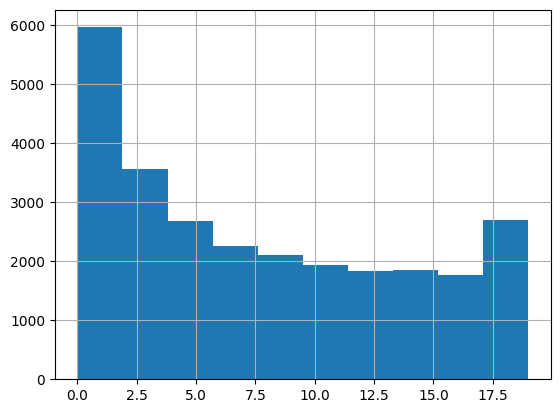

In [18]:
simulation_df["clicked_at"].hist()

## Number of interactions per user per round

In [19]:
simulation_df

,user,item,relevant,clicked_at,timestamp,rating,constant,genres,linear_time,round
0,0,997,1.0,0,0.006199,4.177124,1.0,NaN,NaN,1.0
1,0,1022,1.0,1,0.056479,4.171705,1.0,NaN,NaN,1.0
2,0,764,1.0,2,0.133365,4.135020,1.0,NaN,NaN,1.0
3,0,632,1.0,3,0.141593,4.121809,1.0,NaN,NaN,1.0
4,0,818,1.0,4,0.133878,4.120290,1.0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...
26650,926,1017,1.0,0,108.053520,5.199515,1.0,NaN,NaN,500.0
26651,927,2955,1.0,3,98.901392,5.195721,1.0,NaN,NaN,500.0
26652,962,1039,1.0,4,109.874321,3.401626,1.0,NaN,NaN,500.0
26653,974,2813,1.0,2,130.648249,4.186590,1.0,NaN,NaN,500.0


In [22]:
interactions_per_round = simulation_df.groupby(["user", "round"]).agg({"item": "size"}).reset_index()

In [23]:
interactions_per_round

,user,round,item
0,0,1.0,6
1,0,2.0,5
2,0,3.0,1
3,0,9.0,1
4,0,10.0,1
...,...,...,...
23692,999,411.0,1
23693,999,414.0,1
23694,999,439.0,1
23695,999,484.0,1


In [25]:
import seaborn as sns

In [ ]:
data = interactions_per_round[["round", "item"]]